# Spark SQL

## Spark SQL Engine

Spark SQL allows working with structured data using SQL queries, while relying on Spark’s distributed execution engine. The lifecycle of a Spark SQL query starts with parsing. At this stage, the SQL string is converted into an abstract syntax tree (AST). This tree reflects the structure of the query and ensures that the syntax is correct.

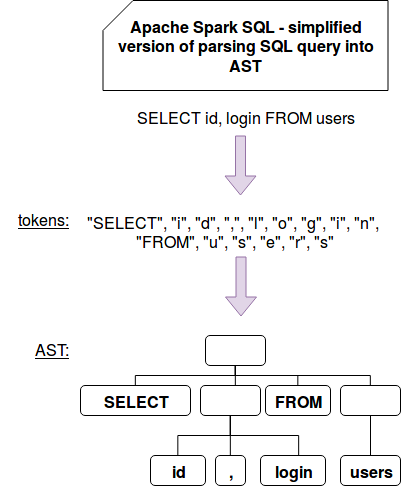

After parsing, Spark performs resolution of the tree. This step is sometimes called creating a resolved logical plan. Here Spark binds column names to actual columns in tables, resolves table references, checks data types, and replaces unresolved attributes with concrete ones from the catalog. In other words, the system moves from a purely syntactic tree to a semantically valid representation of the query.

Next, Spark builds an unoptimized logical plan. This plan describes what operations need to be performed, such as filtering, joining, or aggregating, but does not yet define how they will be executed.

The logical plan is then passed to the Catalyst Optimizer. Catalyst applies a set of rule-based transformations to improve the plan. These include pushing filters closer to the data source to reduce the amount of processed data, removing unused columns, precomputing constant expressions, and selecting more efficient join strategies. The result is an optimized logical plan that reduces unnecessary computation.

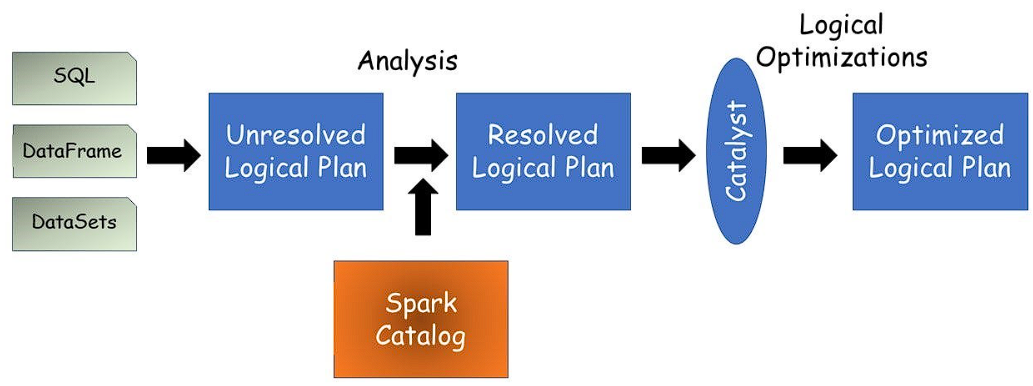

After optimization, Spark generates physical execution plans. At this stage, multiple alternative plans may be created, each representing a different execution strategy. Spark evaluates them and selects the most efficient one based on cost considerations and available resources.

The final step is execution, which is handled by the Tungsten engine. Tungsten focuses on efficient use of memory and CPU. It uses techniques such as whole-stage code generation, where parts of the query are compiled into optimized JVM bytecode, vectorized execution that processes batches of rows instead of individual records, and off-heap memory management to reduce garbage collection overhead.


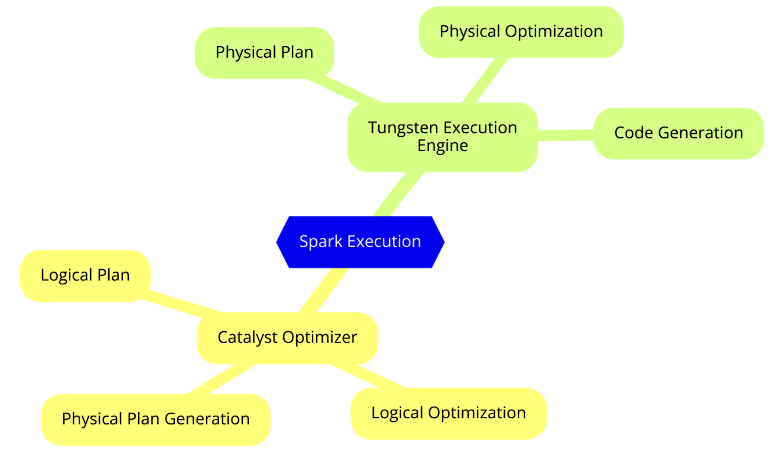


As a result, a high-level SQL query is transformed step by step into an efficient distributed execution plan that runs across the cluster.

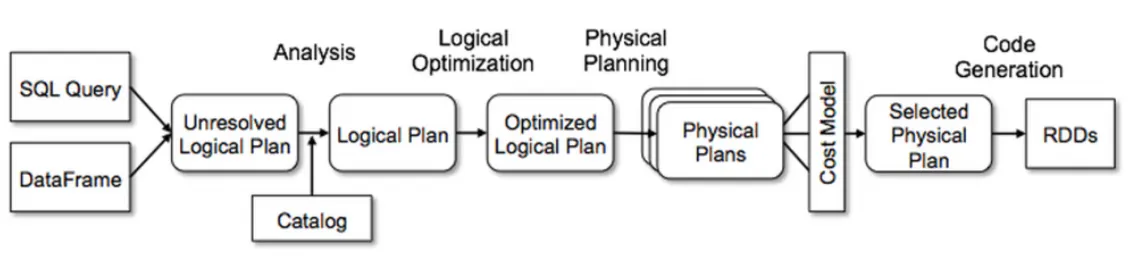

## Data preparation

Let's practise. Read the data.

In [ ]:
%sh
wget -O "/Volumes/workspace/default/study/BigMart Sales.csv" "https://raw.githubusercontent.com/anshlambagit/PySpark-Full-Course/main/DATA%20and%20NOTEBOOK/BigMart%20Sales.csv"

--2026-05-04 11:07:43--  https://raw.githubusercontent.com/anshlambagit/PySpark-Full-Course/main/DATA%20and%20NOTEBOOK/BigMart%20Sales.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 869537 (849K) [text/plain]
Saving to: ‘/Volumes/workspace/default/study/BigMart Sales.csv’

     0K .......... .......... .......... .......... ..........  5% 2.19M 0s
    50K .......... .......... .......... .......... .......... 11% 36.1M 0s
   100K .......... .......... .......... .......... .......... 17% 16.3M 0s
   150K .......... .......... .......... .......... .......... 23% 17.0M 0s
   200K .......... .......... .......... .......... .......... 29% 15.9M 0s
   250K .......... .......... .......... .......... .......... 35% 18.4M 0s
   300K .......... .......... ...

In [ ]:
df = spark.read.format('csv') \
    .option('inferSchema', True) \
    .option('header', True) \
    .load('/Volumes/workspace/default/study/BigMart Sales.csv')
df.limit(10).display()

Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
FDA15,9.3,Low Fat,0.016047301,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138
DRC01,5.92,Regular,0.019278216,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
FDN15,17.5,Low Fat,0.016760075,Meat,141.618,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27
FDX07,19.2,Regular,0.0,Fruits and Vegetables,182.095,OUT010,1998,null,Tier 3,Grocery Store,732.38
NCD19,8.93,Low Fat,0.0,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
FDP36,10.395,Regular,0.0,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
FDO10,13.65,Regular,0.012741089,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
FDP10,null,Low Fat,0.127469857,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
FDH17,16.2,Regular,0.016687114,Frozen Foods,96.9726,OUT045,2002,null,Tier 2,Supermarket Type1,1076.5986
FDU28,19.2,Regular,0.09444959,Frozen Foods,187.8214,OUT017,2007,null,Tier 2,Supermarket Type1,4710.535


Import necessary SQL-like functions.

In [ ]:
from pyspark.sql.types import *
from pyspark.sql.functions import *

## Pivot

Group items by a categorial column (`Item_Fat_Content`). Then for each unique item in another column (`Item_Type`) create a column with demanded information.

In [ ]:
df.groupBy('Item_Fat_Content') \
  .pivot('Item_Type') \
  .agg(avg('Item_Outlet_Sales')) \
  .display()

Item_Fat_Content,Baking Goods,Breads,Breakfast,Canned,Dairy,Frozen Foods,Fruits and Vegetables,Hard Drinks,Health and Hygiene,Household,Meat,Others,Seafood,Snack Foods,Soft Drinks,Starchy Foods
LF,1670.79181,1697.540325,817.6024,1647.7375058823532,1711.2724500000002,2604.6701272727264,2122.0411743589743,2492.505525,1968.0129655172414,2337.488174074074,2601.680079999999,2605.2754,1549.3166,1949.1187612903225,1812.0460357142854,2466.419111111111
Low Fat,1781.8710285714278,2260.1056571428576,2507.863738461538,2231.1233649681503,2172.8208706806263,2094.8219287735847,2181.465001724136,2154.0737809045218,2018.337402910603,2249.430663809522,1989.9547647798738,1900.5901192307695,1986.24785,2434.8894381395326,2035.757150442478,2582.9803472222225
reg,1089.504876923077,969.4047999999999,1916.1724,2002.484290909091,3105.069266666667,2107.1168315789473,2110.0533599999994,null,null,null,2556.0062000000003,null,null,1776.9623043478261,1225.7378,2177.1659999999997
Regular,2192.2814006535937,2265.2612037037034,1925.742032835821,2252.365531986532,2353.8017077519376,2151.9602227390174,2413.159213864821,null,null,null,2232.333436290321,null,2899.2630888888884,2108.920813608247,1863.04156,2141.867315254237
low fat,1345.5818,1221.1881666666666,null,2458.73282,2132.8903,1845.9305,2446.0281454545457,1313.242942857143,1730.7471,2484.2246375000004,3635.268,183.76080000000002,830.9184,2385.1868875,2914.3017142857143,1618.5598


## Conditions

Apply if-else conditions.

In [ ]:
df.withColumn(
  'veg_flag',
  when(col('Item_Type') == 'Meat', 0).otherwise(1)
).limit(10).display()

Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,veg_flag
FDA15,9.3,Low Fat,0.016047301,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,1
DRC01,5.92,Regular,0.019278216,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,1
FDN15,17.5,Low Fat,0.016760075,Meat,141.618,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27,0
FDX07,19.2,Regular,0.0,Fruits and Vegetables,182.095,OUT010,1998,null,Tier 3,Grocery Store,732.38,1
NCD19,8.93,Low Fat,0.0,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,1
FDP36,10.395,Regular,0.0,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088,1
FDO10,13.65,Regular,0.012741089,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528,1
FDP10,null,Low Fat,0.127469857,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636,1
FDH17,16.2,Regular,0.016687114,Frozen Foods,96.9726,OUT045,2002,null,Tier 2,Supermarket Type1,1076.5986,1
FDU28,19.2,Regular,0.09444959,Frozen Foods,187.8214,OUT017,2007,null,Tier 2,Supermarket Type1,4710.535,1


Build a complex condition.

In [ ]:
data = [(2, "Alice"), (5, "Bob"), (50, "Charlie"), (15, "David")]
columns = ["age", "name"]
df = spark.createDataFrame(data, columns)

df_with_status = df.withColumn(
    "status",
    when(col("age") < 18, "Minor")
    .when(col("age") >= 18, "Adult")
    .otherwise("Unknown")
).display()

age,name,status
2,Alice,Minor
5,Bob,Minor
50,Charlie,Adult
15,David,Minor


## SQL-like joins

In [ ]:
dataj1 = [('1', 'gaur', 'd01'),
           ('2', 'kit', 'd02'),
           ('3', 'sam', 'd03'),
           ('4', 'tim', 'd03'),
           ('5', 'aman', 'd05'),
           ('6', 'bebu', 'd06')]
schemaj1 = 'emp_id STRING, emp_name STRING, dept_id STRING'

df1 = spark.createDataFrame(dataj1, schemaj1)

dataj2 = [('d01', 'HR'),
           ('d02', 'Marketing'),
           ('d03', 'Accounts'),
           ('d04', 'IT'),
           ('d05', 'Finance')]
schemaj2 = 'dept_id STRING, department STRING'

df2 = spark.createDataFrame(dataj2, schemaj2)

In [ ]:
for join_type in ('inner', 'left', 'right', 'anti'):
  df1.join(df2, df1['dept_id'] == df2['dept_id'], join_type).display()

emp_id,emp_name,dept_id,dept_id,department
1,gaur,d01,d01,HR
2,kit,d02,d02,Marketing
3,sam,d03,d03,Accounts
4,tim,d03,d03,Accounts
5,aman,d05,d05,Finance


emp_id,emp_name,dept_id,dept_id,department
1,gaur,d01,d01,HR
2,kit,d02,d02,Marketing
3,sam,d03,d03,Accounts
4,tim,d03,d03,Accounts
5,aman,d05,d05,Finance
6,bebu,d06,null,null


emp_id,emp_name,dept_id,dept_id,department
1,gaur,d01,d01,HR
2,kit,d02,d02,Marketing
4,tim,d03,d03,Accounts
3,sam,d03,d03,Accounts
null,null,null,d04,IT
5,aman,d05,d05,Finance


emp_id,emp_name,dept_id
6,bebu,d06


## Transformations

Traditionally, transformations can be divided into two groups:

| Aspect | Narrow | Wide |
|---|---|---|
| Concept | Each output partition depends only on a single input partition. No shuffle; data stays local. | Each output partition depends on multiple input partitions. Requires a shuffle. |
| Examples | map, filter, flatMap, mapPartitions, union (when partitions align), pipe | groupByKey, reduceByKey, join, distinct, repartition, coalesce, aggregateByKey |

## Join Mechanics

### Shuffle hash join

Join in Spark is a wide transformation, because rows from two DataFrames may live in different partitions, and Spark has to move data across the cluster so that matching keys end up together.

Before a join, the existing partitions are just the input layout. When Spark begins the join it creates a shuffle stage. During the shuffle Spark assigns each record to a new partition by hashing the join key. By default `spark.sql.shuffle.partitions` is 200, so records are redistributed into 200 shuffle partitions. For example, key 1 and key 201 can land in the same partition because 1 % 200 = 1 and 201 % 200 = 1. But AQE can change this number based on the situation, for instance 200 to 10.

After the shuffle each partition is processed independently and Spark compares rows that share the same join key. If one side of the join is small, Spark may choose a broadcast join and avoid the shuffle. After processing the shuffled partitions Spark completes the join and produces the final result.


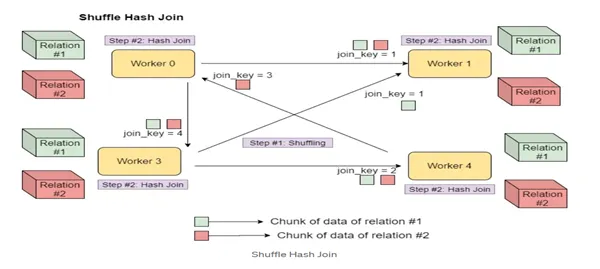

In [ ]:
df1 = spark.createDataFrame(
    [(1, "A"), (2, "B"), (201, "C"), (3, "D")],
    ["id", "value1"]
)

df2 = spark.createDataFrame(
    [(1, "X"), (201, "Y"), (4, "Z"), (2, "W")],
    ["id", "value2"]
)

In [ ]:
df1.display()
df2.display()

id,value1
1,A
2,B
201,C
3,D


id,value2
1,X
201,Y
4,Z
2,W


In [ ]:
spark.conf.set("spark.sql.join.preferSortMergeJoin", "false")
df1.join(df2, "id").display()
spark.conf.set("spark.sql.join.preferSortMergeJoin", "true")


### Sort-merge join

The default strategy for large joins in Spark is sort-merge join. It is used when both sides are too large to broadcast and the join keys are sortable. After the shuffle step that we described above, Spark does not immediately start comparing rows. Instead, within each of the 200 partitions it first sorts the data by the join key on both sides.

Once both sides are sorted, Spark performs a merge phase. It iterates through the sorted data from left and right partitions in a streaming manner, similar to how merge works in merge sort. Because the data is already grouped by key due to sorting, Spark can efficiently match rows without scanning the entire partition multiple times. This makes sort-merge join scalable for large datasets, but takes more time for sorting.


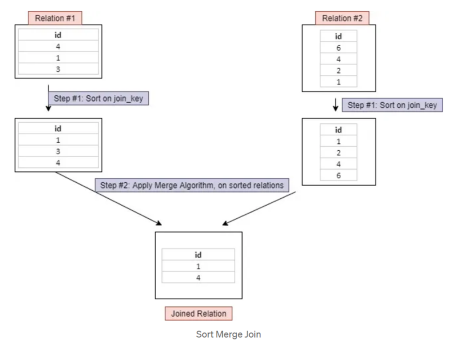

In [ ]:
df1.join(df2, "id").display()

id,value1,value2
1,A,X
2,B,W
201,C,Y


### Broadcast variable

A broadcast variable places copies of an object on all worker nodes for further evaluation. This is typically used for small datasets or objects, as it is more efficient to process them locally on each node rather than sending them from the driver repeatedly.

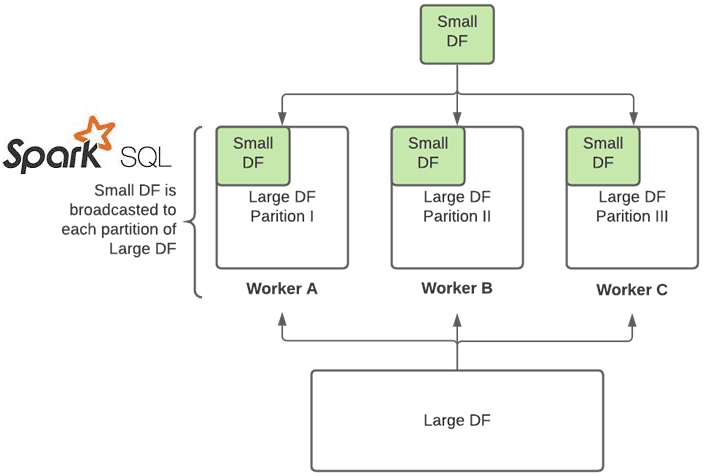

In [ ]:
df = spark.createDataFrame([
    ("1001",),
    ("1002",),
    ("1004",),
], ["product_id"])

product_dict = {
    "1001": "iPhone",
    "1002": "Samsung",
    "1003": "Pixel"
}


In [ ]:
broad = spark.sparkContext.broadcast(product_dict)
broad.value

In [ ]:
def mymap(x):
    return broad.value.get(x)

bmap = udf(mymap)
df_named = df.withColumn('name', bmap('product_id'))
df_named.toPandas()

,product_id,name
0,1001,iPhone
1,1002,Samsung
2,1004,None


### Broadcast with SQL Syntax

First, create these Dataframes.

In [ ]:
df_transactions = spark.createDataFrame([
    (1, "US", 100),
    (2, "IN", 200),
    (3, "UK", 150),
    (4, "US", 80),
], ["id", "country_code", "amount"])

df_countries = spark.createDataFrame([
    ("US", "United States"),
    ("IN", "India"),
    ("UK", "United Kingdom"),
], ["country_code", "country_name"])


In [ ]:
df_join = df_transactions.join(broadcast(df_countries), on="country_code", how="inner")
df_join.display()

country_code,id,amount,country_name
US,1,100,United States
IN,2,200,India
UK,3,150,United Kingdom
US,4,80,United States


Use `broadcast` in SQL.

In [ ]:
df_transactions.createOrReplaceTempView('transactions')
df_countries.createOrReplaceTempView('countries')

In [ ]:
df_sql_opt = spark.sql("""
    SELECT /*+ BROADCAST(c) */ *
    FROM transactions t
    JOIN countries c
    ON t.country_code = c.country_code
""")

In [ ]:
df_sql_opt.limit(10).display()

id,country_code,amount,country_code,country_name
1,US,100,US,United States
2,IN,200,IN,India
3,UK,150,UK,United Kingdom
4,US,80,US,United States



### Broadcast hash join

Broadcast hash join is used when one of the DataFrames is small enough to fit in memory. Instead of shuffling both sides, Spark sends the smaller dataset to every executor. This is the broadcast phase. Then Spark builds a hash table from the small dataset inside each executor. The join key is used to organize the data into buckets, so lookup becomes very fast. Then Spark scans the partitions of the large DataFrame and probes the hash table to find matching rows.

Because the hash table is local to each executor, there is no need to move the large dataset across the network. This strategy avoids both shuffle and sort, which makes it significantly faster.


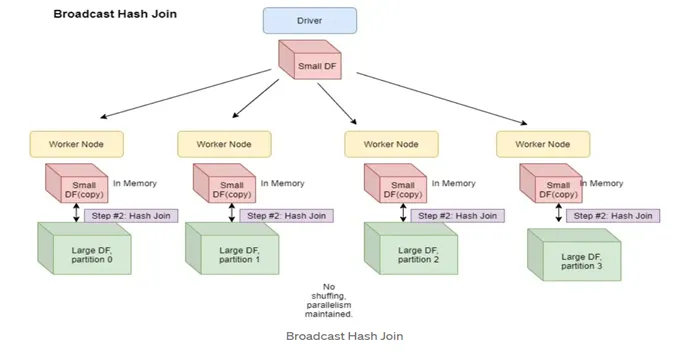

In [ ]:
from pyspark.sql.functions import broadcast

df1.join(broadcast(df2), "id").display()

id,value1,value2
1,A,X
2,B,W
201,C,Y


### Broadcast Nested Loop Join

Broadcast Nested Loop Join is the simplest strategy: Spark broadcasts one entire dataset to every executor and then performs a nested loop, meaning every row from the large dataset is compared with every row from the broadcasted one. There is no hashing or sorting involved, just a brute-force comparison.


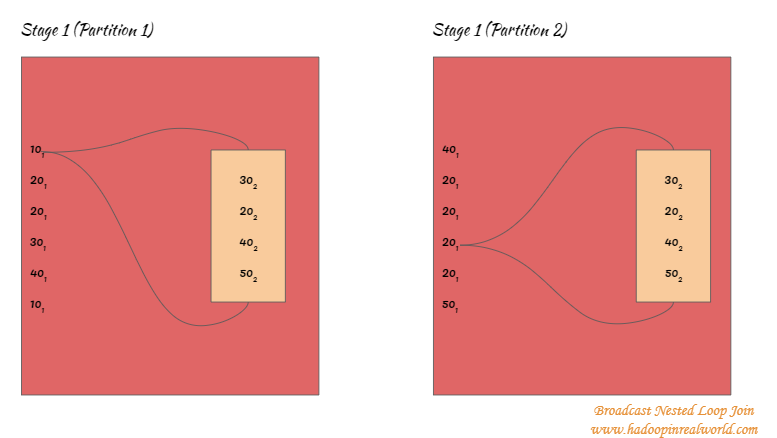

### Equi and Non-Equi Joins

Equi join is a join where the condition is based on equality of keys, for example `df1.id == df2.id`, while non-equi join uses other conditions such as >, <, !=. In the example, Spark cannot use hash-based or sort-merge strategies that rely on equality, and instead falls back to Broadcast Nested Loop Join, where the small dataset is broadcasted and every pair of rows is checked against the condition.

In [ ]:
from pyspark.sql.functions import broadcast

df1.join(broadcast(df2), df1.id > df2.id).display()

id,value1,id,value2
2,B,1,X
201,C,1,X
201,C,4,Z
201,C,2,W
3,D,1,X
3,D,2,W


### Cartesian Product Join

Cartesian Product Join works similarly in terms of nested loop logic, but without broadcasting. Instead, Spark replicates partitions across executors so that every partition from one dataset can be compared with every partition from the other. This is sometimes called shuffle-and-replication, although it is not a key-based shuffle. The result is a full cross product of the two datasets, which is extremely expensive and usually avoided unless explicitly required.

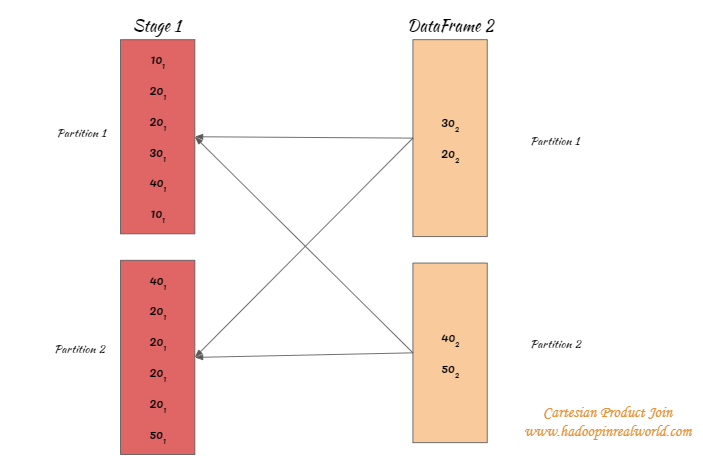

In [ ]:
df1.crossJoin(df2).display()

id,value1,id,value2
1,A,1,X
1,A,201,Y
1,A,4,Z
1,A,2,W
2,B,1,X
2,B,201,Y
2,B,4,Z
2,B,2,W
201,C,1,X
201,C,201,Y


## Window functions

`Window` is a class used to define a frame of rows. By calling its methods, you build a specification that tells Spark exactly how to partition and order data for your calculations.

In [ ]:
from pyspark.sql.window import Window

In [ ]:
df = spark.read.format('csv') \
    .option('inferSchema', True) \
    .option('header', True) \
    .load('/Volumes/workspace/default/study/BigMart Sales.csv')
df.limit(10).display()

Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
FDA15,9.3,Low Fat,0.016047301,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138
DRC01,5.92,Regular,0.019278216,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
FDN15,17.5,Low Fat,0.016760075,Meat,141.618,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27
FDX07,19.2,Regular,0.0,Fruits and Vegetables,182.095,OUT010,1998,null,Tier 3,Grocery Store,732.38
NCD19,8.93,Low Fat,0.0,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
FDP36,10.395,Regular,0.0,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
FDO10,13.65,Regular,0.012741089,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
FDP10,null,Low Fat,0.127469857,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
FDH17,16.2,Regular,0.016687114,Frozen Foods,96.9726,OUT045,2002,null,Tier 2,Supermarket Type1,1076.5986
FDU28,19.2,Regular,0.09444959,Frozen Foods,187.8214,OUT017,2007,null,Tier 2,Supermarket Type1,4710.535


Make a column with row ids.

In [ ]:
df.withColumn('index', monotonically_increasing_id()).limit(10).display()

Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,index
FDA15,9.3,Low Fat,0.016047301,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,0
DRC01,5.92,Regular,0.019278216,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,1
FDN15,17.5,Low Fat,0.016760075,Meat,141.618,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27,2
FDX07,19.2,Regular,0.0,Fruits and Vegetables,182.095,OUT010,1998,null,Tier 3,Grocery Store,732.38,3
NCD19,8.93,Low Fat,0.0,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,4
FDP36,10.395,Regular,0.0,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088,5
FDO10,13.65,Regular,0.012741089,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528,6
FDP10,null,Low Fat,0.127469857,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636,7
FDH17,16.2,Regular,0.016687114,Frozen Foods,96.9726,OUT045,2002,null,Tier 2,Supermarket Type1,1076.5986,8
FDU28,19.2,Regular,0.09444959,Frozen Foods,187.8214,OUT017,2007,null,Tier 2,Supermarket Type1,4710.535,9


Sort and number the rows. We always need to apply functions like `orderBy` while using `Window` because `Spark` hasn't a guaranteed built-in index and doesn't preserve row order. The reason is the data is usually distributed across several partitions that can be loaded and processed separately.

In [ ]:
window_spec = Window.orderBy(col('Item_Identifier'))
df_numbered = df.withColumn('rowCol', row_number().over(window_spec))
df_numbered.limit(10).display()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,rowCol
DRA12,11.6,Low Fat,0.041112694,Soft Drinks,142.0154,OUT018,2009,Medium,Tier 3,Supermarket Type2,850.8924,1
DRA12,11.6,Low Fat,0.0,Soft Drinks,141.6154,OUT045,2002,null,Tier 2,Supermarket Type1,3829.0158,2
DRA12,11.6,Low Fat,0.040911824,Soft Drinks,142.3154,OUT013,1987,High,Tier 3,Supermarket Type1,2552.6772,3
DRA12,11.6,Low Fat,0.068535039,Soft Drinks,143.0154,OUT010,1998,null,Tier 3,Grocery Store,283.6308,4
DRA12,11.6,Low Fat,0.041177505,Soft Drinks,140.3154,OUT017,2007,null,Tier 2,Supermarket Type1,2552.6772,5
DRA12,11.6,LF,0.0,Soft Drinks,141.9154,OUT035,2004,Small,Tier 2,Supermarket Type1,992.7078,6
DRA24,19.35,Regular,0.066831682,Soft Drinks,163.8868,OUT010,1998,null,Tier 3,Grocery Store,327.5736,7
DRA24,19.35,Regular,0.040154087,Soft Drinks,164.6868,OUT017,2007,null,Tier 2,Supermarket Type1,1146.5076,8
DRA24,19.35,Regular,0.039920687,Soft Drinks,163.3868,OUT035,2004,Small,Tier 2,Supermarket Type1,3439.5228,9
DRA24,null,Regular,0.069909188,Soft Drinks,163.2868,OUT019,1985,Small,Tier 1,Grocery Store,491.3604,10


Sort the values within the column and assign ranks. Compare the behaviour of `rank` and `dense_rank`.

In [ ]:
datar = [(1, 'A'), (2, 'A'), (3, 'B'), (4, 'C'), (5, 'C')]
dfr = spark.createDataFrame(datar, ['id', 'category'])
window_spec = Window.orderBy("category")
dfr.withColumn("rank", rank().over(window_spec)) \
    .withColumn('dense_rank', dense_rank().over(window_spec)) \
    .display()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


id,category,rank,dense_rank
1,A,1,1
2,A,1,1
3,B,3,2
4,C,4,3
5,C,4,3


Cumulative sum.

In [ ]:
df.withColumn('cumsum', sum('Item_MRP') \
    .over(Window.orderBy('Item_MRP') \
    .rowsBetween(Window.unboundedPreceding, Window.currentRow))) \
    .limit(10) \
    .display()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,cumsum
DRK12,null,Low Fat,0.041683481,Soft Drinks,31.29,OUT027,1985,Medium,Tier 3,Supermarket Type3,898.83,31.29
DRK12,9.5,Low Fat,0.041851461,Soft Drinks,31.49,OUT013,1987,High,Tier 3,Supermarket Type1,466.06,62.78
DRK12,9.5,Low Fat,0.042056944,Soft Drinks,31.89,OUT018,2009,Medium,Tier 3,Supermarket Type2,366.19,94.67
FDX59,10.195,Low Fat,0.051618281,Breads,31.9558,OUT013,1987,High,Tier 3,Supermarket Type1,373.5138,126.6258
FDG40,null,Low Fat,0.039631495,Frozen Foods,31.9558,OUT027,1985,Medium,Tier 3,Supermarket Type3,984.7182,158.5816
FDV28,16.1,Regular,0.159698192,Frozen Foods,32.0558,OUT035,2004,Small,Tier 2,Supermarket Type1,1018.674,190.6374
DRK12,9.5,LF,0.042123243,Soft Drinks,32.09,OUT017,2007,null,Tier 2,Supermarket Type1,432.77,222.72740000000002
FDU21,11.8,reg,0.07665661,Snack Foods,32.3558,OUT013,1987,High,Tier 3,Supermarket Type1,169.779,255.08320000000003
NCO06,19.25,Low Fat,0.108030434,Household,32.4558,OUT046,1997,Small,Tier 1,Supermarket Type1,101.8674,287.53900000000004
DRK12,9.5,Low Fat,0.041951439,Soft Drinks,32.49,OUT049,1999,Medium,Tier 1,Supermarket Type1,865.54,320.02900000000005


Moving average.

In [ ]:
df.withColumn('moving_average', avg(col('Item_MRP')) \
    .over(Window.orderBy('Item_MRP') \
    .rowsBetween(-2, 0))) \
    .limit(10) \
    .display()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,moving_average
DRK12,null,Low Fat,0.041683481,Soft Drinks,31.29,OUT027,1985,Medium,Tier 3,Supermarket Type3,898.83,31.29
DRK12,9.5,Low Fat,0.041851461,Soft Drinks,31.49,OUT013,1987,High,Tier 3,Supermarket Type1,466.06,31.39
DRK12,9.5,Low Fat,0.042056944,Soft Drinks,31.89,OUT018,2009,Medium,Tier 3,Supermarket Type2,366.19,31.55666666666667
FDX59,10.195,Low Fat,0.051618281,Breads,31.9558,OUT013,1987,High,Tier 3,Supermarket Type1,373.5138,31.778599999999997
FDG40,null,Low Fat,0.039631495,Frozen Foods,31.9558,OUT027,1985,Medium,Tier 3,Supermarket Type3,984.7182,31.933866666666663
FDV28,16.1,Regular,0.159698192,Frozen Foods,32.0558,OUT035,2004,Small,Tier 2,Supermarket Type1,1018.674,31.98913333333333
DRK12,9.5,LF,0.042123243,Soft Drinks,32.09,OUT017,2007,null,Tier 2,Supermarket Type1,432.77,32.03386666666667
FDU21,11.8,reg,0.07665661,Snack Foods,32.3558,OUT013,1987,High,Tier 3,Supermarket Type1,169.779,32.1672
NCO06,19.25,Low Fat,0.108030434,Household,32.4558,OUT046,1997,Small,Tier 1,Supermarket Type1,101.8674,32.300533333333334
DRK12,9.5,Low Fat,0.041951439,Soft Drinks,32.49,OUT049,1999,Medium,Tier 1,Supermarket Type1,865.54,32.43386666666667


`ffill` implementation in `Spark`. We process the DataFrame and fill null values with the last non-null value. The `last()` function, with `ignorenulls=True`, returns the most recent non-null entry within a defined window.

In [ ]:
dataf = [(1, None), (2, 20), (3, None), (4, 40), (5, None)]
columns = ['id', 'value']
dff = spark.createDataFrame(dataf, columns)

window_spec = Window.orderBy('id').rowsBetween(Window.unboundedPreceding, Window.currentRow)
dff.withColumn('value_ffill', last('value', ignorenulls=True).over(window_spec)).display()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


id,value,value_ffill
1,null,null
2,20,20
3,null,20
4,40,40
5,null,40


## Spark with SQL

Create a temporary `SQL` view that is available only during the current `Spark` session.

In [ ]:
df.createTempView('my_view')

Count the rows where `Item_Fat_Content='Low Fat'`

In [ ]:
%sql
SELECT count(1)
FROM my_view
WHERE Item_Fat_Content = 'Low Fat'

count(1)
5089


Process `SQL` expression within `Python` code.

In [ ]:
df_sql = spark.sql("""
    SELECT *
    FROM my_view
    WHERE Item_Fat_Content = 'Low Fat'
""")
df_sql.limit(10).display()

Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
FDA15,9.3,Low Fat,0.016047301,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138
FDN15,17.5,Low Fat,0.016760075,Meat,141.618,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27
NCD19,8.93,Low Fat,0.0,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
FDP10,null,Low Fat,0.127469857,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
FDY07,11.8,Low Fat,0.0,Fruits and Vegetables,45.5402,OUT049,1999,Medium,Tier 1,Supermarket Type1,1516.0266
FDF32,16.35,Low Fat,0.0680243,Fruits and Vegetables,196.4426,OUT013,1987,High,Tier 3,Supermarket Type1,1977.426
NCB42,11.8,Low Fat,0.008596051,Health and Hygiene,115.3492,OUT018,2009,Medium,Tier 3,Supermarket Type2,1621.8888
DRI11,null,Low Fat,0.034237682,Hard Drinks,113.2834,OUT027,1985,Medium,Tier 3,Supermarket Type3,2303.668
FDU02,13.35,Low Fat,0.10249212,Dairy,230.5352,OUT035,2004,Small,Tier 2,Supermarket Type1,2748.4224
NCB30,14.6,Low Fat,0.025698134,Household,196.5084,OUT035,2004,Small,Tier 2,Supermarket Type1,1587.2672
